## Model

In [1]:
from river_model import RiverModel
from constants import VEC_T, VEC_TOBS

### Instanciate model + free run : State variables : Q

In [2]:
forward_model = RiverModel(par_k_in = 0.5, par_x_in = 0.3)

In [3]:
q_out_ts = forward_model.run()

### Diagnostic variables : H

Known law relating Q and H

In [4]:
h_out_ts = forward_model.estimate_height(q_out_ts)

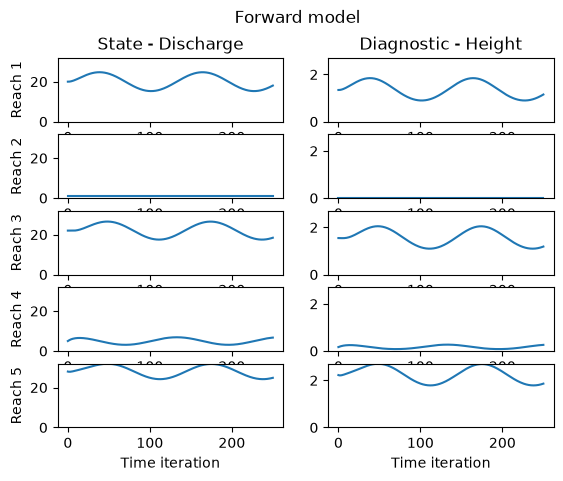

In [5]:
forward_model.plot(q_out_ts, h_out_ts, title="Forward model")

## Observations

### Available observations set

In [6]:
dct_obs_1 = {
    "yobs": [ 28.031, 31.354, 28.918, 26.057, 25.365, 26.536, 29.751, 30.046, 26.028, 26.167 ],
    "variable": "q",
    "reach": [5]
}

In [7]:
dct_obs_2 = {
    "yobs": [ 2.345, 2.594, 2.340, 2.028, 1.921, 2.086, 2.391, 2.312, 2.029, 1.949 ],
    "variable": "h",
    "reach": [5]
}

In [8]:
dct_obs_3 = {
    "yobs": [ 21.910, 26.992, 24.554, 19.885, 17.863, 19.427, 26.036, 23.850, 20.655, 19.492 ],
    "variable": "q",
    "reach": [3]
}

### Model vs observations

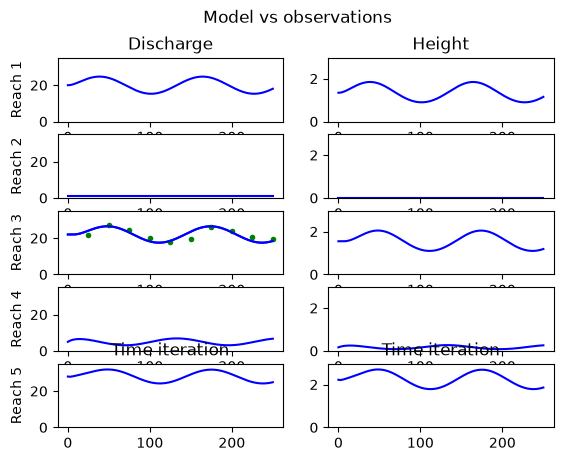

In [9]:
from bayes_estimator import DAExperiment
assim_base = DAExperiment(forward_model=forward_model,
                        dct_obs=dct_obs_3)
assim_base.plot_model_vs_obs()

### [Bonus] Sensitivity analysis

In [ ]:
from sensitivity_analysis import SensitivityAnalysisRiver
my_analysis = SensitivityAnalysisRiver()
my_analysis.generate_sample()
my_analysis.generate_outputs_ensemble()
my_analysis.estimate_sobol_ensemble()
my_analysis.plot_sensitivity_indices()

/work/scratch/env/emerych/.conda/envs/sig_py314/lib/python3.14/site-packages/SALib/analyze/sobol.py:216: UserWarning: Constant values encountered, indicating model evaluations (or subset of evaluations) produced identical values.
  warn(CONST_RESULT_MSG)


## State estimation

### Control

In [ ]:
dct_ctl = {
    "exp": "state"
}

### Observations

In [ ]:
dct_obs = dct_obs_1

### Sequential state estimation

In [ ]:
state_assim = DAExperiment(forward_model=forward_model, dct_obs=dct_obs_3, dct_ctl=dct_ctl)

In [ ]:
state_assim.sig_o = 0.5
state_assim.sig_b = 0.75
state_assim.perform_assim()
## Ajouter calcul de statistiques

In [ ]:
from constants import SIG_B_Q, SIG_O_Q
import numpy as np
B_in = np.array([
        [SIG_B_Q**2., 0., 0., 0., SIG_B_Q**2.*0.0625],
        [0., SIG_B_Q**2., 0., 0., SIG_B_Q**2.*0.125],
        [0., 0., SIG_B_Q**2., 0., SIG_B_Q**2.*0.25],
        [0., 0., 0., SIG_B_Q**2., SIG_B_Q**2.*0.5],
        [SIG_B_Q**2.*0.0625, SIG_B_Q**2.*0.125, SIG_B_Q**2.*0.25, SIG_B_Q**2.*0.5, SIG_B_Q**2.]
    ])
state_assim = DAExperiment(forward_model=forward_model, dct_obs=dct_obs_1, dct_ctl=dct_ctl)
state_assim.sig_o = SIG_O_Q
state_assim.sig_b = SIG_B_Q
state_assim.perform_assim(b_in=B_in)

In [ ]:
from constants import SIG_B_K
dct_ctl = {
    "exp": "parameter"
}
param_assim = DAExperiment(forward_model=forward_model, dct_obs=dct_obs_1, dct_ctl=dct_ctl)
param_assim.sig_o = SIG_O_Q
param_assim.sig_b = SIG_B_K
param_assim.perform_assim()